# To do: add V315

# Evaluate the Prompt U-Net models against each other
### This evaluation run uses FLARE_2022 and HaNSeg

In [1]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from evaluation.eval_prompt_unet.eval_p_unet_pipeline import PromptUNetTester

dimensions = ['x', 'y', 'z'] 
offsets = [30]
models = [
    'p_unet_21.keras',
    'p_unet_313.keras',
    'p_unet_314.keras',
    'p_unet_320.keras',
]

max_data_points = 750 # must be large enough, for datagen to capture more unique tasks and axis 
models_dir = "training/"

E0000 00:00:1776927391.221621     218 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776927391.229195     218 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776927391.247704     218 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776927391.247734     218 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776927391.247769     218 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776927391.247799     218 computation_placer.cc:177] computation placer already registered. Please check linka

### 1. Evaluate on HanSeg (MRI)

--- RUNNING HANSEG (MRI) EVALUATION ---

Loading NPZ dataset(s)…
Loaded 42 PIDs from /home/dpxuser/prompt-unet/data/test_data/han_seg_mri.npz

Final dataset size: 42 patients.


   EVALUATING OFFSET: 30 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 7 seconds


I0000 00:00:1776927444.928749     218 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46640 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:81:00.0, compute capability: 8.6



--- [SECTION 1: METRICS] ---


I0000 00:00:1776927453.758022     263 cuda_dnn.cc:529] Loaded cuDNN version 91002


Testing p_unet_21.keras... Done. Took 3.2 seconds.
[p_unet_21.keras] -> Avg Dice: 0.588
Testing p_unet_313.keras... Done. Took 3.9 seconds.
[p_unet_313.keras] -> Avg Dice: 0.594
Testing p_unet_314.keras... Done. Took 2.0 seconds.
[p_unet_314.keras] -> Avg Dice: 0.565
Testing p_unet_320.keras... Done. Took 1.8 seconds.
[p_unet_320.keras] -> Avg Dice: 0.584

--- [SECTION 2: VISUALIZATIONS] ---

>> Visualizing predictions for: p_unet_21.keras (Threshold: 0.5)


I0000 00:00:1776927495.676085     261 service.cc:152] XLA service 0x7fb335b6d6e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776927495.676157     261 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1776927499.034201     261 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


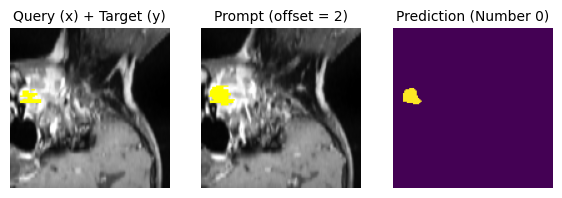

Dice: 0.719



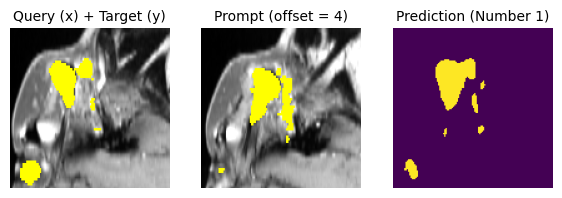

Dice: 0.767


>> Visualizing predictions for: p_unet_313.keras (Threshold: 0.5)


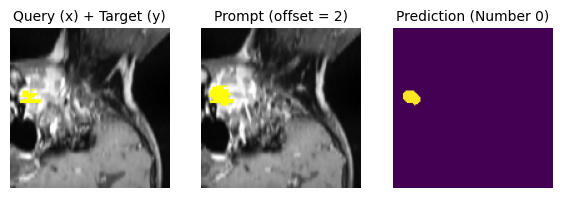

Dice: 0.735



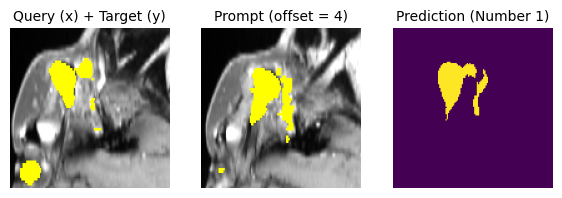

Dice: 0.632


>> Visualizing predictions for: p_unet_314.keras (Threshold: 0.5)


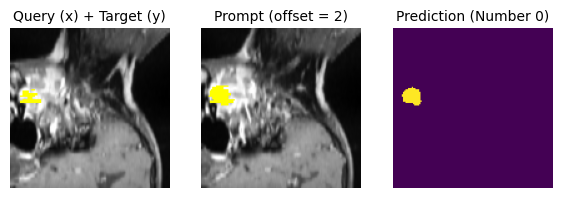

Dice: 0.703



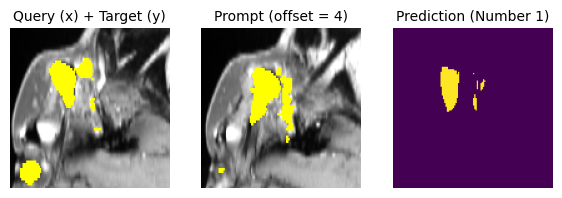

Dice: 0.533


>> Visualizing predictions for: p_unet_320.keras (Threshold: 0.5)


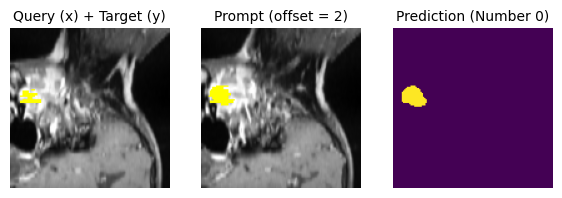

Dice: 0.606



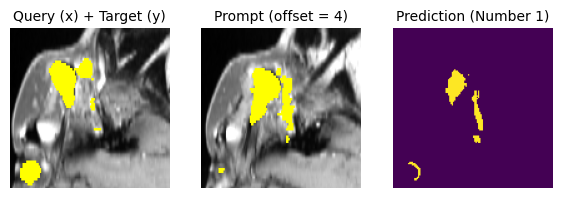

Dice: 0.361



In [2]:
print("--- RUNNING HANSEG (MRI) EVALUATION ---")
dataset_path = ["data/test_data/han_seg_mri.npz"]

# Initialize tester
tester = PromptUNetTester(
    dataset_path=dataset_path,
    models_dir=models_dir,
    max_data_points=max_data_points
)

# Execute full validation loop
results_hanseg = tester.run_pipeline(
    dimensions=dimensions, 
    offsets=offsets, 
    models=models, 
    threshold=0.5, 
    num_visualize=2
)

### 2. Evaluate on HanSeg (CT)

--- RUNNING HANSEG (CT) EVALUATION ---

Loading NPZ dataset(s)…
Loaded 42 PIDs from /home/dpxuser/prompt-unet/data/test_data/han_seg_ct.npz

Final dataset size: 42 patients.


   EVALUATING OFFSET: 30 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 32 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 2.0 seconds.
[p_unet_21.keras] -> Avg Dice: 0.651
Testing p_unet_313.keras... Done. Took 2.1 seconds.
[p_unet_313.keras] -> Avg Dice: 0.710
Testing p_unet_314.keras... Done. Took 2.0 seconds.
[p_unet_314.keras] -> Avg Dice: 0.695
Testing p_unet_320.keras... Done. Took 1.8 seconds.
[p_unet_320.keras] -> Avg Dice: 0.681

--- [SECTION 2: VISUALIZATIONS] ---

>> Visualizing predictions for: p_unet_21.keras (Threshold: 0.5)


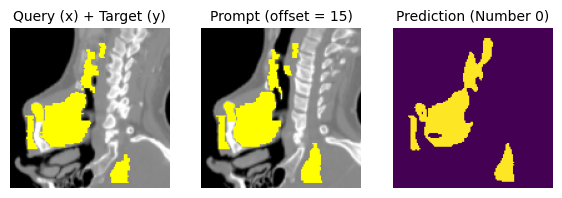

Dice: 0.885



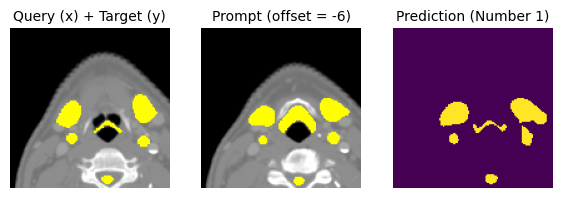

Dice: 0.774


>> Visualizing predictions for: p_unet_313.keras (Threshold: 0.5)


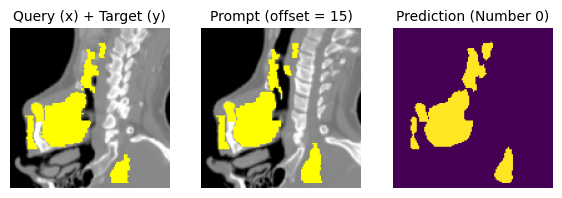

Dice: 0.909



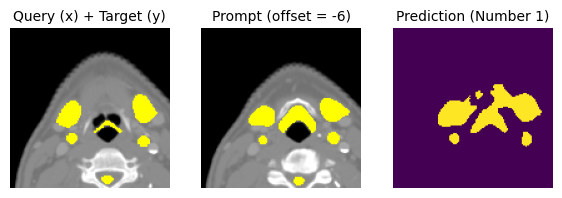

Dice: 0.607


>> Visualizing predictions for: p_unet_314.keras (Threshold: 0.5)


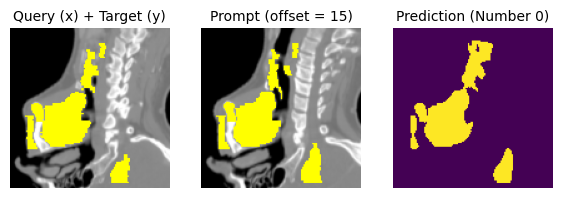

Dice: 0.895



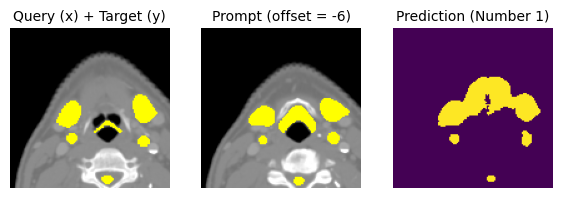

Dice: 0.539


>> Visualizing predictions for: p_unet_320.keras (Threshold: 0.5)


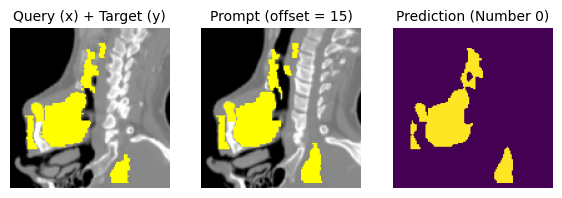

Dice: 0.890



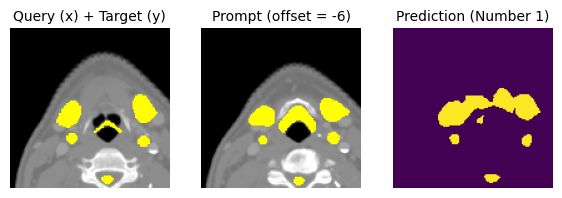

Dice: 0.642



In [3]:
print("--- RUNNING HANSEG (CT) EVALUATION ---")
dataset_path = ["data/test_data/han_seg_ct.npz"]

# Initialize tester
tester = PromptUNetTester(
    dataset_path=dataset_path,
    models_dir=models_dir,
    max_data_points=max_data_points
)

# Execute full validation loop 
results_hanseg = tester.run_pipeline(
    dimensions=dimensions, 
    offsets=offsets, 
    models=models, 
    threshold=0.5, 
    num_visualize=2
)

### 3. Evaluate on FLARE (CT)

--- RUNNING FLARE (CT) EVALUATION ---

Loading NPZ dataset(s)…
Loaded 50 PIDs from /home/dpxuser/prompt-unet/data/test_data/FLARE_2022.npz

Final dataset size: 50 patients.


   EVALUATING OFFSET: 30 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 12 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 1.9 seconds.
[p_unet_21.keras] -> Avg Dice: 0.798
Testing p_unet_313.keras... Done. Took 2.0 seconds.
[p_unet_313.keras] -> Avg Dice: 0.879
Testing p_unet_314.keras... Done. Took 1.9 seconds.
[p_unet_314.keras] -> Avg Dice: 0.874
Testing p_unet_320.keras... Done. Took 1.8 seconds.
[p_unet_320.keras] -> Avg Dice: 0.864

--- [SECTION 2: VISUALIZATIONS] ---

>> Visualizing predictions for: p_unet_21.keras (Threshold: 0.5)


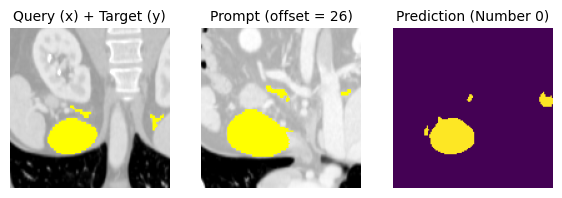

Dice: 0.800



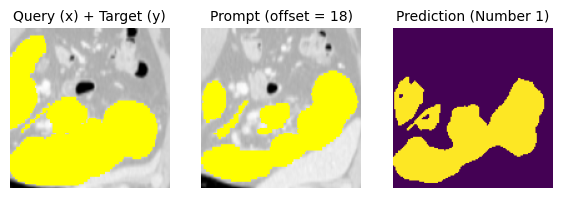

Dice: 0.742


>> Visualizing predictions for: p_unet_313.keras (Threshold: 0.5)


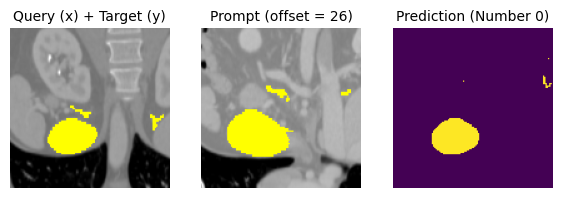

Dice: 0.901



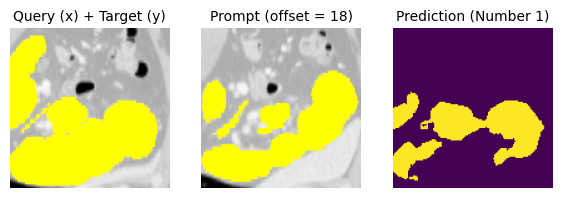

Dice: 0.635


>> Visualizing predictions for: p_unet_314.keras (Threshold: 0.5)


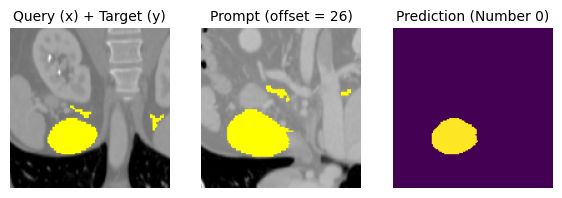

Dice: 0.904



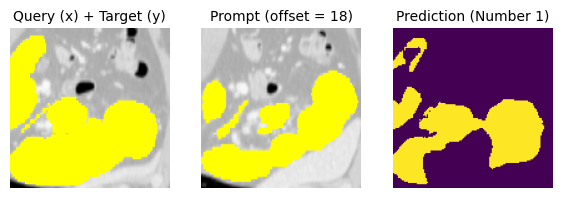

Dice: 0.742


>> Visualizing predictions for: p_unet_320.keras (Threshold: 0.5)


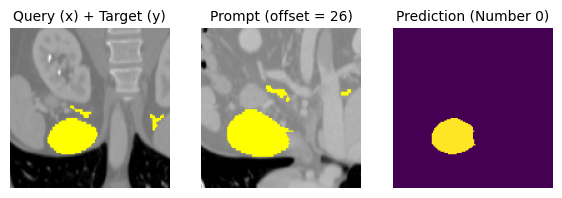

Dice: 0.876



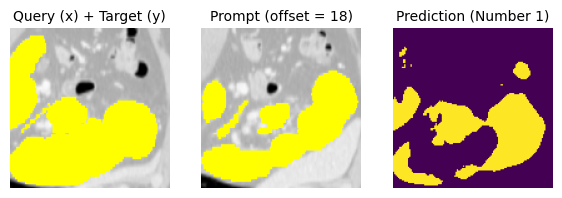

Dice: 0.675



In [4]:
print("--- RUNNING FLARE (CT) EVALUATION ---")
dataset_path = ["data/test_data/FLARE_2022.npz"]

# Initialize tester
tester = PromptUNetTester(
    dataset_path=dataset_path,
    models_dir=models_dir,
    max_data_points=max_data_points
)

# Execute full validation loop
results_flare = tester.run_pipeline(
    dimensions=dimensions, 
    offsets=offsets, 
    models=models, 
    threshold=0.5, 
    num_visualize=2
)

### 4. Evaluate on BraTS GLI (MRI)

--- RUNNING BraTS (MRI) EVALUATION ---

Loading NPZ dataset(s)…
Loaded 271 PIDs from /home/dpxuser/prompt-unet/data/test_data/BraTS_GLI_t1c.npz
Loaded 271 PIDs from /home/dpxuser/prompt-unet/data/test_data/BraTS_GLI_t1n.npz
Loaded 271 PIDs from /home/dpxuser/prompt-unet/data/test_data/BraTS_GLI_t2f.npz
Loaded 271 PIDs from /home/dpxuser/prompt-unet/data/test_data/BraTS_GLI_t2w.npz

Final dataset size: 1084 patients.


   EVALUATING OFFSET: 30 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 2 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 1.9 seconds.
[p_unet_21.keras] -> Avg Dice: 0.556
Testing p_unet_313.keras... Done. Took 2.0 seconds.
[p_unet_313.keras] -> Avg Dice: 0.597
Testing p_unet_314.keras... Done. Took 2.0 seconds.
[p_unet_314.keras] -> Avg Dice: 0.586
Testing p_unet_320.keras... Done. Took 1.9 seconds.
[p_unet_320.keras] -> Avg Dice: 0.543

--- [SECTION 2: VISUALIZATIONS] ---

>> Visualizing predictions for: p_unet_21.keras (Thresh

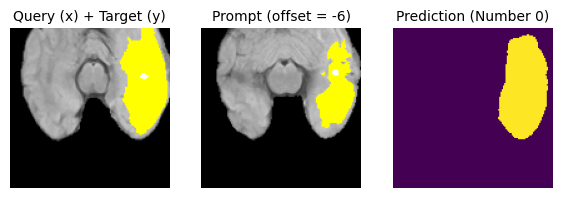

Dice: 0.852



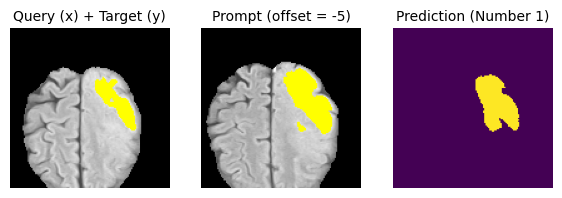

Dice: 0.701


>> Visualizing predictions for: p_unet_313.keras (Threshold: 0.5)


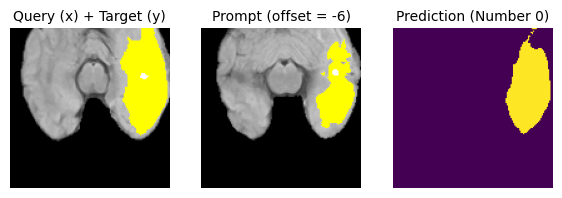

Dice: 0.882



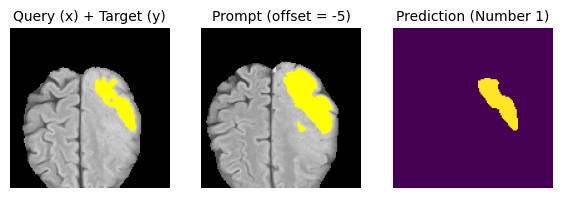

Dice: 0.932


>> Visualizing predictions for: p_unet_314.keras (Threshold: 0.5)


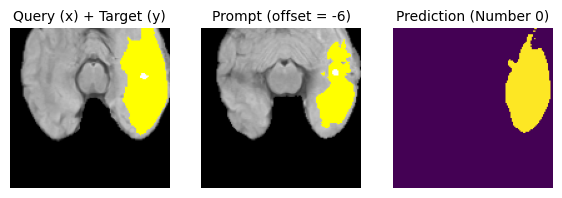

Dice: 0.886



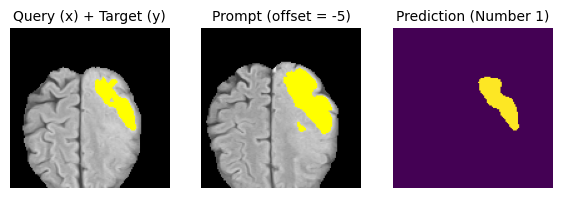

Dice: 0.906


>> Visualizing predictions for: p_unet_320.keras (Threshold: 0.5)


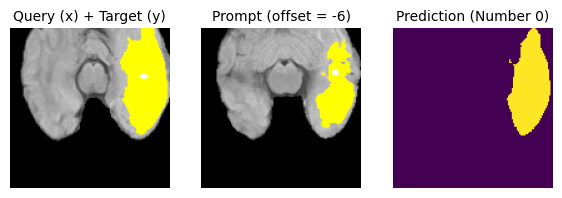

Dice: 0.903



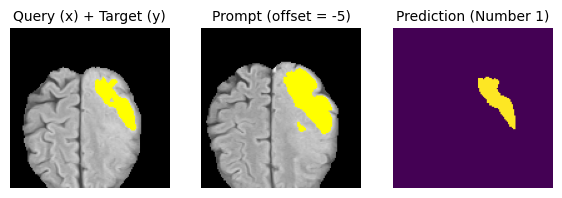

Dice: 0.907



In [5]:
print("--- RUNNING BraTS (MRI) EVALUATION ---")
dataset_path = ["data/test_data/BraTS_GLI_t1c.npz", "data/test_data/BraTS_GLI_t1n.npz", "data/test_data/BraTS_GLI_t2f.npz", "data/test_data/BraTS_GLI_t2w.npz",]

# Initialize tester
tester = PromptUNetTester(
    dataset_path=dataset_path,
    models_dir=models_dir,
    max_data_points=max_data_points
)

# Execute full validation loop
results_flare = tester.run_pipeline(
    dimensions=dimensions, 
    offsets=offsets, 
    models=models, 
    threshold=0.5, 
    num_visualize=2
)

### 5. Evaluate on BraTS MEN RT (MRI)

--- RUNNING BraTS (MRI) EVALUATION ---

Loading NPZ dataset(s)…
Loaded 250 PIDs from /home/dpxuser/prompt-unet/data/test_data/BraTS_MEN_RT.npz

Final dataset size: 250 patients.


   EVALUATING OFFSET: 30 | AXIS: ['x', 'y', 'z']

Creating new Data Points ...
It took 5 seconds

--- [SECTION 1: METRICS] ---
Testing p_unet_21.keras... Done. Took 2.0 seconds.
[p_unet_21.keras] -> Avg Dice: 0.674
Testing p_unet_313.keras... Done. Took 2.0 seconds.
[p_unet_313.keras] -> Avg Dice: 0.766
Testing p_unet_314.keras... Done. Took 2.0 seconds.
[p_unet_314.keras] -> Avg Dice: 0.736
Testing p_unet_320.keras... Done. Took 1.8 seconds.
[p_unet_320.keras] -> Avg Dice: 0.724

--- [SECTION 2: VISUALIZATIONS] ---

>> Visualizing predictions for: p_unet_21.keras (Threshold: 0.5)


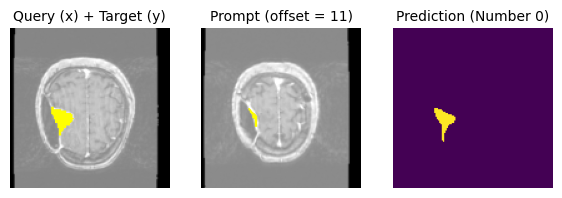

Dice: 0.879



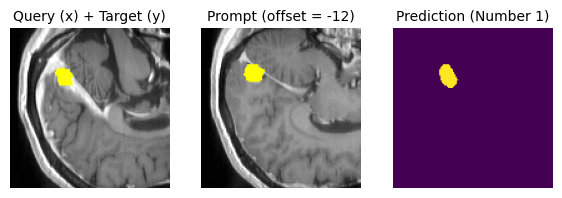

Dice: 0.853


>> Visualizing predictions for: p_unet_313.keras (Threshold: 0.5)


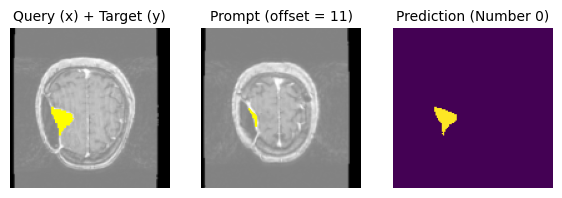

Dice: 0.926



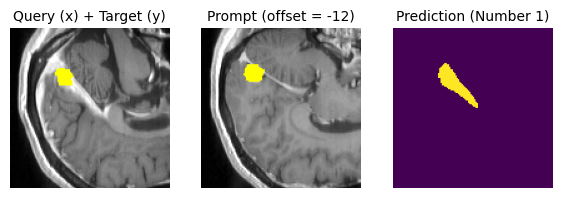

Dice: 0.583


>> Visualizing predictions for: p_unet_314.keras (Threshold: 0.5)


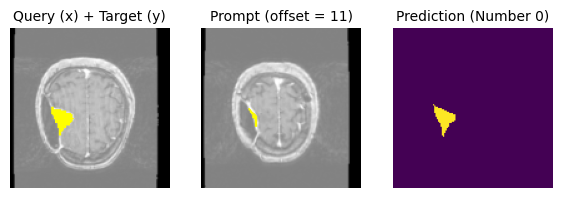

Dice: 0.933



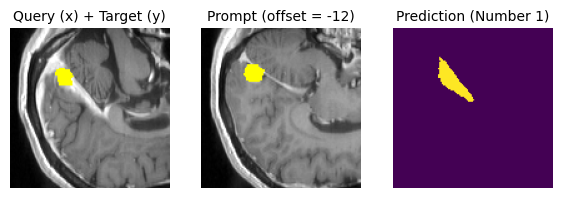

Dice: 0.586


>> Visualizing predictions for: p_unet_320.keras (Threshold: 0.5)


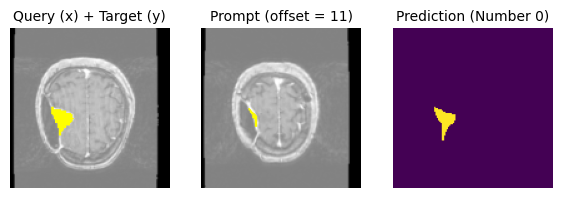

Dice: 0.894



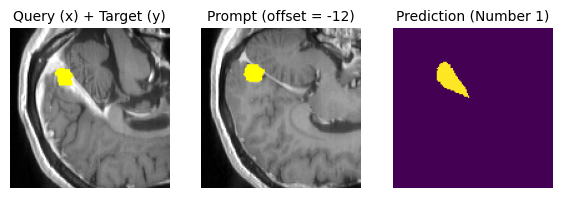

Dice: 0.623



In [6]:
print("--- RUNNING BraTS (MRI) EVALUATION ---")
dataset_path = ["data/test_data/BraTS_MEN_RT.npz"]

# Initialize tester
tester = PromptUNetTester(
    dataset_path=dataset_path,
    models_dir=models_dir,
    max_data_points=max_data_points
)

# Execute full validation loop
results_flare = tester.run_pipeline(
    dimensions=dimensions, 
    offsets=offsets, 
    models=models, 
    threshold=0.5, 
    num_visualize=2
)